In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data
import yfinance as yf


In [2]:
start = '2014-01-01'
end = '2025-12-31'

df = yf.download('AAPL', start=start, end=end)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2014-01-02,17.140663,17.261519,17.106266,17.219684,234684800
2014-01-03,16.764153,17.158325,16.747108,17.132296,392467600
2014-01-06,16.855572,16.944508,16.535460,16.654767,412610800
2014-01-07,16.735023,16.918475,16.669328,16.867654,317209200
2014-01-08,16.841007,16.906082,16.693192,16.696910,258529600


In [3]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-12-23,272.105377,272.245261,269.308007,270.586809,29642000
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800
2025-12-29,273.504089,274.103504,272.095404,272.435082,23715200
2025-12-30,272.824707,273.823772,272.025467,272.554970,22139600


In [4]:
df = df.reset_index()

df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2014-01-02,17.140663,17.261519,17.106266,17.219684,234684800
1,2014-01-03,16.764153,17.158325,16.747108,17.132296,392467600
2,2014-01-06,16.855572,16.944508,16.535460,16.654767,412610800
3,2014-01-07,16.735023,16.918475,16.669328,16.867654,317209200
4,2014-01-08,16.841007,16.906082,16.693192,16.696910,258529600


In [5]:
df.columns = df.columns.get_level_values(0)

In [6]:
df = df.drop(['Date'], axis=1, errors='ignore')
df.head()

Price,Close,High,Low,Open,Volume
0,17.140663,17.261519,17.106266,17.219684,234684800
1,16.764153,17.158325,16.747108,17.132296,392467600
2,16.855572,16.944508,16.535460,16.654767,412610800
3,16.735023,16.918475,16.669328,16.867654,317209200
4,16.841007,16.906082,16.693192,16.696910,258529600


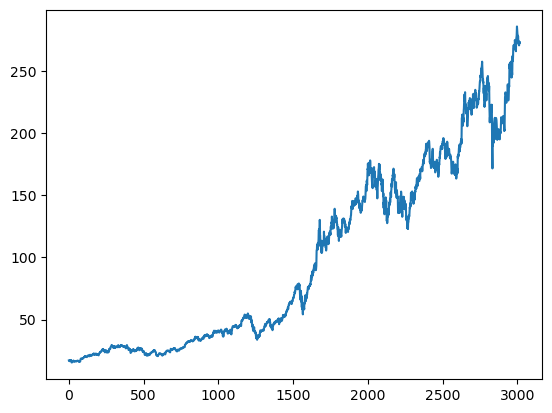

In [7]:
plt.plot(df.Close)

In [8]:
df

Price,Close,High,Low,Open,Volume
0,17.140663,17.261519,17.106266,17.219684,234684800
1,16.764153,17.158325,16.747108,17.132296,392467600
2,16.855572,16.944508,16.535460,16.654767,412610800
3,16.735023,16.918475,16.669328,16.867654,317209200
4,16.841007,16.906082,16.693192,16.696910,258529600
...,...,...,...,...,...
3012,272.105377,272.245261,269.308007,270.586809,29642000
3013,273.554016,275.172497,271.945536,272.085389,17910600
3014,273.144409,275.112569,272.604905,273.903708,21521800
3015,273.504089,274.103504,272.095404,272.435082,23715200


In [9]:
ma100 = df.Close.rolling(100).mean()
ma100

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
3012    253.811870
3013    254.520079
3014    255.228480
3015    255.837490
3016    256.372113
Name: Close, Length: 3017, dtype: float64

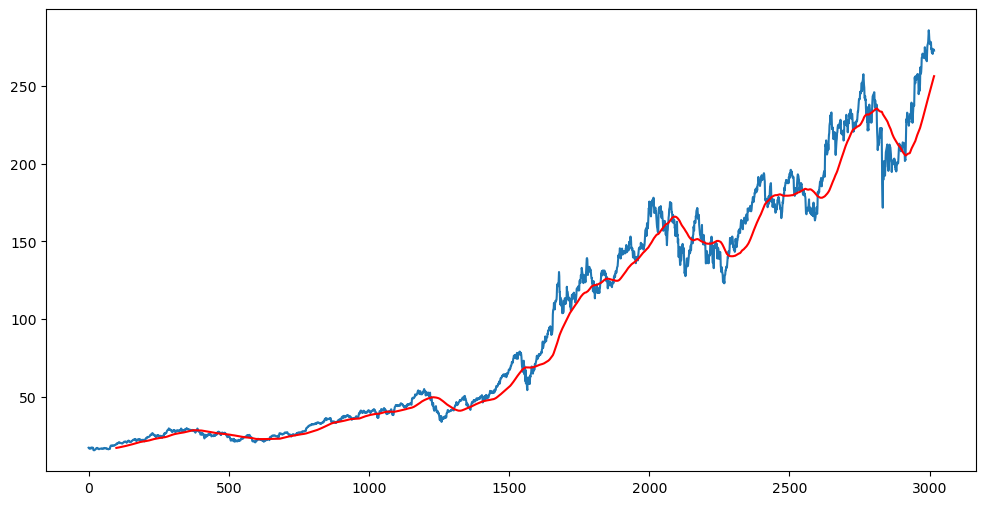

In [10]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')

In [11]:
ma200 = df.Close.rolling(200).mean()
ma200

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
3012    229.717952
3013    229.986314
3014    230.271844
3015    230.595514
3016    230.896820
Name: Close, Length: 3017, dtype: float64

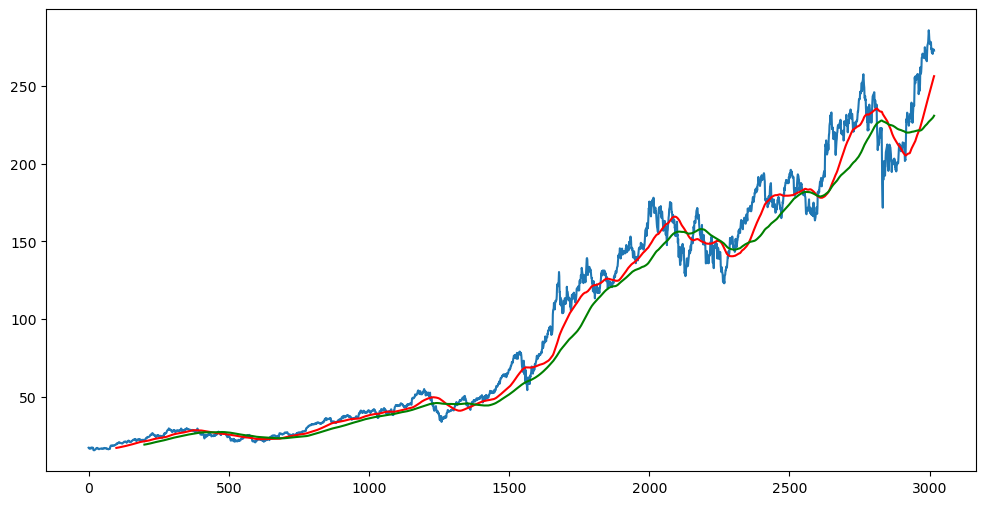

In [12]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')
plt.plot(ma200, 'g')

In [13]:
df.shape

(3017, 5)

In [14]:
# Splitting Data into Training and Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(2111, 1)
(906, 1)


In [15]:
data_training.head()

,Close
0,17.140663
1,16.764153
2,16.855572
3,16.735023
4,16.841007


In [16]:
data_testing.head()

,Close
2111,135.006607
2112,140.423004
2113,137.724594
2114,137.881638
2115,141.080399


In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [18]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.01016653],
       [0.00785119],
       [0.00841337],
       ...,
       [0.80527324],
       [0.75446701],
       [0.73352908]], shape=(2111, 1))

In [19]:
data_training_array.shape

(2111, 1)

In [20]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [21]:
x_train.shape

(2011, 100, 1)

In [22]:
# ML Model

In [23]:
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.models import Sequential

In [24]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
              input_shape =(x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

C:\Users\ARPITA CHOUDHURY\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer = 'adam' , loss = 'mean_squared_error')
model.fit(x_train, y_train , epochs = 50)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 313ms/step - loss: 0.0295
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 312ms/step - loss: 0.0063
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 341ms/step - loss: 0.0050
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 326ms/step - loss: 0.0047
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 290ms/step - loss: 0.0050
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 274ms/step - loss: 0.0044
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 302ms/step - loss: 0.0041
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 256ms/step - loss: 0.0039
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 259ms/step - loss: 0.0037
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 270ms/step - loss: 0.0037
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 270ms/step - loss: 0.0042
Epoch 12/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 256ms/step - loss: 0.0039
Epoch 13/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 233ms/step - loss: 0.0033
Epoch 14/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 265ms/step - loss: 0.0033
Epoch 15/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 

In [27]:
model.save('my_model.keras')

In [28]:
data_testing.head()

,Close
2111,135.006607
2112,140.423004
2113,137.724594
2114,137.881638
2115,141.080399


In [29]:
data_training.tail(100)

,Close
2011,175.442047
2012,175.530121
2013,174.375427
2014,173.758957
2015,178.103622
...,...
2106,144.347870
2107,142.807312
2108,146.437897
2109,138.175980


In [30]:
past_100_days = data_training.tail(100)

In [31]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [32]:
final_df.head()

,Close
0,175.442047
1,175.530121
2,174.375427
3,173.758957
4,178.103622


In [33]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.32168861],
       [0.32222935],
       [0.31513993],
       ...,
       [0.92154723],
       [0.92375554],
       [0.91958437]], shape=(1006, 1))

In [34]:
input_data.shape

(1006, 1)

In [35]:
x_test = []
y_test = []

for i in range (100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [36]:
x_test, y_test = np.array(x_test) , np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(906, 100, 1)
(906,)


In [37]:
# Making Predictions

y_predicted = model.predict(x_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step


In [38]:
y_predicted.shape

(906, 1)

In [39]:
y_test

array([7.34290290e-02, 1.06683829e-01, 9.01165270e-02, 9.10807194e-02,
       1.10720003e-01, 1.46022821e-01, 1.41203265e-01, 1.40420163e-01,
       1.55481125e-01, 1.20359022e-01, 1.24937437e-01, 1.40420163e-01,
       1.35901893e-01, 1.03852052e-01, 7.06577723e-02, 3.90299768e-02,
       4.43313485e-02, 6.04165541e-02, 2.80655207e-02, 3.71021541e-02,
       6.30672400e-02, 5.99346453e-02, 7.75257224e-02, 9.79483884e-02,
       9.79483884e-02, 7.25254500e-02, 8.33090029e-02, 6.81878959e-02,
       8.15016575e-02, 9.73458151e-02, 1.05538921e-01, 1.26202635e-01,
       1.30359379e-01, 1.17286666e-01, 1.23250850e-01, 1.21021740e-01,
       1.38974343e-01, 1.49215748e-01, 1.30540283e-01, 1.54215927e-01,
       1.66505726e-01, 1.80422061e-01, 1.72831154e-01, 1.65963579e-01,
       1.57830618e-01, 1.89097169e-01, 1.92470812e-01, 2.23556460e-01,
       2.17532225e-01, 2.08495592e-01, 2.45364801e-01, 2.43436979e-01,
       2.42049523e-01, 2.39153667e-01, 2.39455516e-01, 2.65516721e-01,
      

In [40]:
y_predicted

array([[0.18412644],
       [0.17933121],
       [0.17432463],
       [0.1691749 ],
       [0.1639705 ],
       [0.15883887],
       [0.15398374],
       [0.14960542],
       [0.14586262],
       [0.14288104],
       [0.1406816 ],
       [0.13921928],
       [0.13843423],
       [0.13824782],
       [0.13852552],
       [0.13906789],
       [0.13960388],
       [0.13984919],
       [0.13958254],
       [0.13860431],
       [0.13679028],
       [0.13414957],
       [0.13078713],
       [0.12690175],
       [0.1227715 ],
       [0.11867815],
       [0.11481394],
       [0.11131193],
       [0.10822619],
       [0.10557751],
       [0.10338636],
       [0.10167593],
       [0.10049012],
       [0.09987442],
       [0.0998437 ],
       [0.10039043],
       [0.10148524],
       [0.10310023],
       [0.10521493],
       [0.10778113],
       [0.11075798],
       [0.1141163 ],
       [0.11783903],
       [0.12190026],
       [0.1262526 ],
       [0.13082044],
       [0.13554162],
       [0.140

In [41]:
scaler.scale_

array([0.00613965])

In [42]:
scale_factor = 1/0.02143827
y_predicted = y_predicted*scale_factor
y_test = y_test*scale_factor

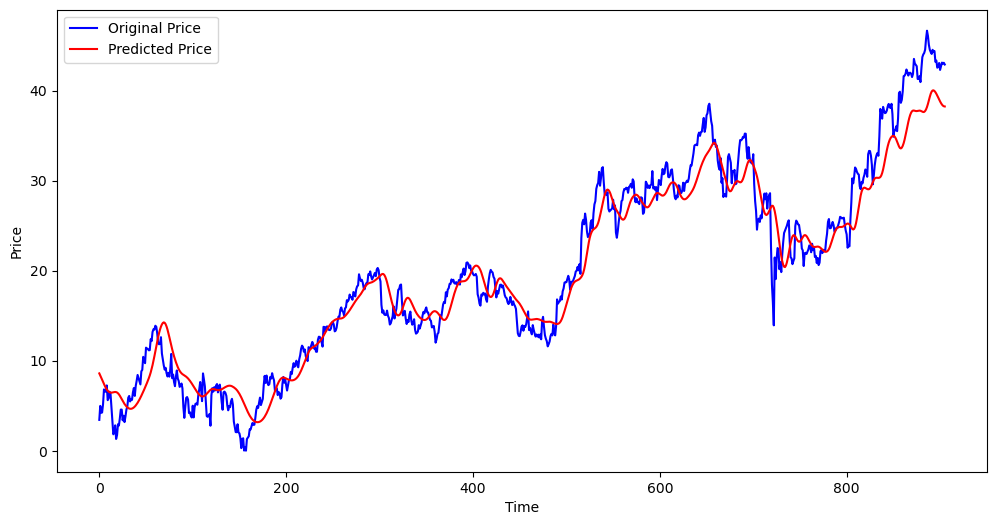

In [43]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b' , label = 'Original Price')
plt.plot(y_predicted, 'r' , label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show() 